In [29]:
import numpy as np

print("--- Binary Classification Problem ---")

a0 = -5
a1 = 0.8

print(f"a. Logistic Regression Equation:\nP(pass) = 1 / (1 + e^(-(-5 + 0.8 * study_hours)))")

study_hours = 7
z = a0 + a1 * study_hours
probability_pass = 1 / (1 + np.exp(-z))
print(f"b. Probability of passing for a student studying 7 hours: {probability_pass:.4f}")


threshold = 0.5
predicted_class = "Pass" if probability_pass >= threshold else "Fail"
print(f"c. Predicted class for this student (threshold = 0.5): {predicted_class}")

print("\n--- Softmax Function Application (Slide 4, Q2) ---")

logits = np.array([2, 1, 0])

exponentials = np.exp(logits)

sum_exponentials = np.sum(exponentials)


softmax_probabilities = exponentials / sum_exponentials

print(f"a. Logits z = {logits}")
print(f"   Softmax probabilities: {softmax_probabilities}")
print(f"   (Sum of probabilities: {np.sum(softmax_probabilities):.4f})")

--- Binary Classification Problem ---
a. Logistic Regression Equation:
P(pass) = 1 / (1 + e^(-(-5 + 0.8 * study_hours)))
b. Probability of passing for a student studying 7 hours: 0.6457
c. Predicted class for this student (threshold = 0.5): Pass

--- Softmax Function Application (Slide 4, Q2) ---
a. Logits z = [2 1 0]
   Softmax probabilities: [0.66524096 0.24472847 0.09003057]
   (Sum of probabilities: 1.0000)


In [30]:
import pandas as pd

hr_df = pd.read_csv('/content/HR_comma_sep.csv')

print("--- First 5 rows of the dataset ---")
print(hr_df.head())

print("\n--- DataFrame Information ---")
hr_df.info()

print("\n--- Statistical Summary ---")
print(hr_df.describe())

--- First 5 rows of the dataset ---
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

  

/tmp/ipython-input-306/3079680181.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='salary', y='left', data=hr_df, errorbar=None, palette='viridis')


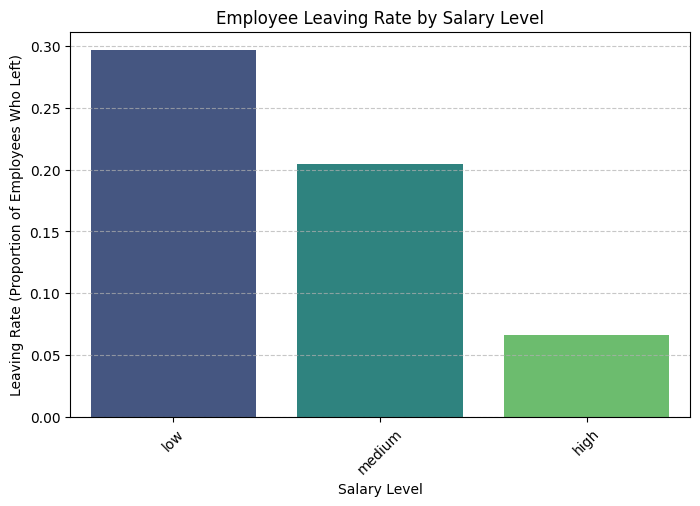


--- Employee Leaving Rate by Salary Level ---
salary
low       0.296884
medium    0.204313
high      0.066289
Name: left, dtype: float64


/tmp/ipython-input-306/3079680181.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Department', y='left', data=hr_df, errorbar=None, palette='mako')


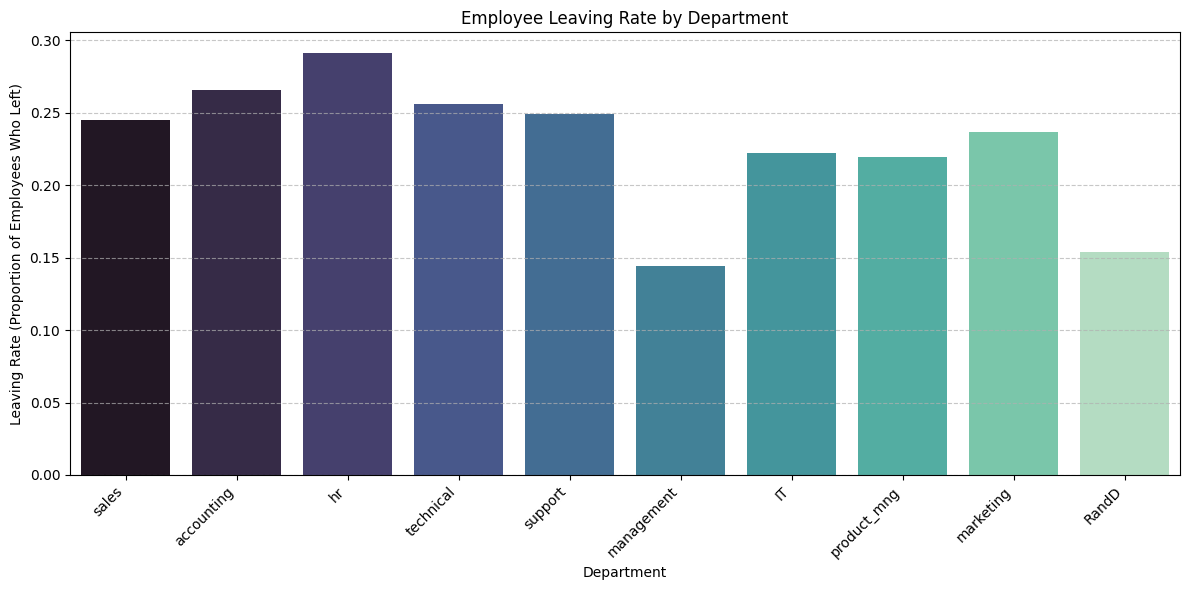


--- Employee Leaving Rate by Department ---
Department
hr             0.290934
accounting     0.265971
technical      0.256250
support        0.248991
sales          0.244928
marketing      0.236597
IT             0.222494
product_mng    0.219512
RandD          0.153748
management     0.144444
Name: left, dtype: float64


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 5))
sns.barplot(x='salary', y='left', data=hr_df, errorbar=None, palette='viridis')
plt.title('Employee Leaving Rate by Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Leaving Rate (Proportion of Employees Who Left)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n--- Employee Leaving Rate by Salary Level ---")
print(hr_df.groupby('salary')['left'].mean().sort_values(ascending=False))

plt.figure(figsize=(12, 6))
sns.barplot(x='Department', y='left', data=hr_df, errorbar=None, palette='mako')
plt.title('Employee Leaving Rate by Department')
plt.xlabel('Department')
plt.ylabel('Leaving Rate (Proportion of Employees Who Left)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n--- Employee Leaving Rate by Department ---")
print(hr_df.groupby('Department')['left'].mean().sort_values(ascending=False))

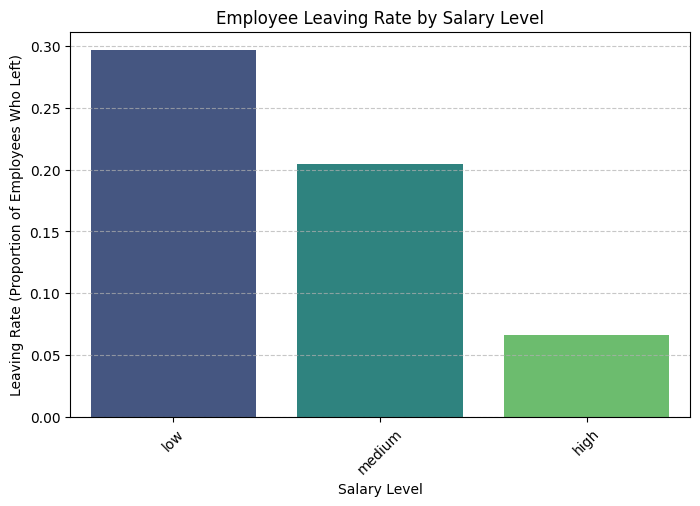


--- Employee Leaving Rate by Salary Level ---
salary
low       0.296884
medium    0.204313
high      0.066289
Name: left, dtype: float64


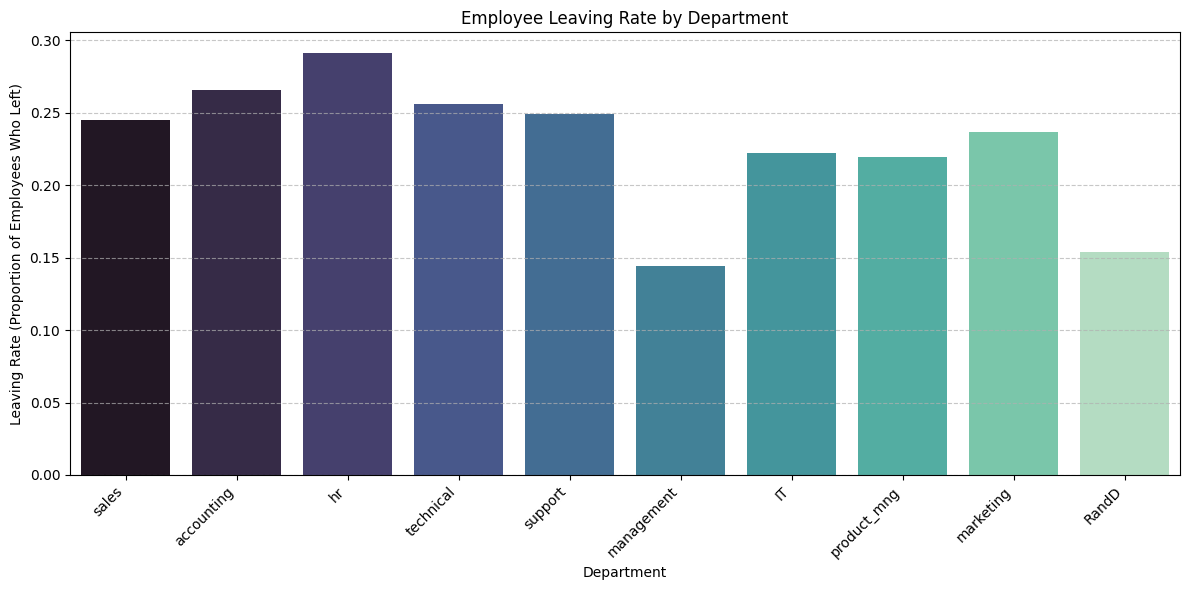


--- Employee Leaving Rate by Department ---
Department
hr             0.290934
accounting     0.265971
technical      0.256250
support        0.248991
sales          0.244928
marketing      0.236597
IT             0.222494
product_mng    0.219512
RandD          0.153748
management     0.144444
Name: left, dtype: float64


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 5))
sns.barplot(x='salary', y='left', data=hr_df, errorbar=None, palette='viridis', hue='salary', legend=False)
plt.title('Employee Leaving Rate by Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Leaving Rate (Proportion of Employees Who Left)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n--- Employee Leaving Rate by Salary Level ---")
print(hr_df.groupby('salary')['left'].mean().sort_values(ascending=False))

plt.figure(figsize=(12, 6))
sns.barplot(x='Department', y='left', data=hr_df, errorbar=None, palette='mako', hue='Department', legend=False)
plt.title('Employee Leaving Rate by Department')
plt.xlabel('Department')
plt.ylabel('Leaving Rate (Proportion of Employees Who Left)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n--- Employee Leaving Rate by Department ---")
print(hr_df.groupby('Department')['left'].mean().sort_values(ascending=False))

In [33]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

X = hr_df.drop('left', axis=1)
y = hr_df['left']

categorical_features = ['Department', 'salary']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

X_encoded = preprocessor.fit_transform(X)

categorical_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

remaining_feature_names = X.columns.drop(categorical_features).tolist()

all_feature_names = list(categorical_feature_names) + remaining_feature_names

X_encoded_df = pd.DataFrame(X_encoded, columns=all_feature_names)

print("--- Features (X) after one-hot encoding ---")
print(X_encoded_df.head())
print(f"\nShape of X_encoded_df: {X_encoded_df.shape}")

--- Features (X) after one-hot encoding ---
   Department_IT  Department_RandD  Department_accounting  Department_hr  \
0            0.0               0.0                    0.0            0.0   
1            0.0               0.0                    0.0            0.0   
2            0.0               0.0                    0.0            0.0   
3            0.0               0.0                    0.0            0.0   
4            0.0               0.0                    0.0            0.0   

   Department_management  Department_marketing  Department_product_mng  \
0                    0.0                   0.0                     0.0   
1                    0.0                   0.0                     0.0   
2                    0.0                   0.0                     0.0   
3                    0.0                   0.0                     0.0   
4                    0.0                   0.0                     0.0   

   Department_sales  Department_support  Department_te

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X_encoded_df, y, test_size=0.3, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Shape of X_train: (10499, 20)
Shape of X_test: (4500, 20)
Shape of y_train: (10499,)
Shape of y_test: (4500,)
Logistic Regression model trained successfully.


Model Accuracy: 0.7858

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      3428
           1       0.59      0.34      0.43      1072

    accuracy                           0.79      4500
   macro avg       0.70      0.63      0.65      4500
weighted avg       0.76      0.79      0.76      4500


--- Confusion Matrix ---
[[3175  253]
 [ 711  361]]


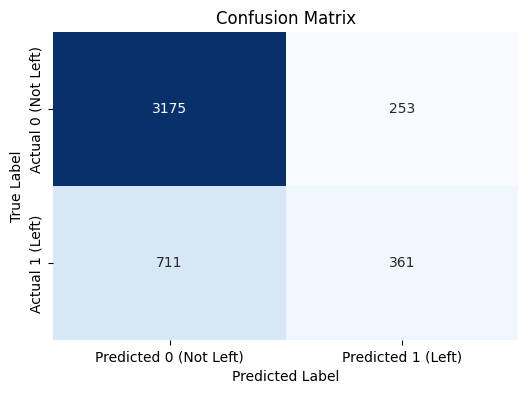

In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
print("\n--- Confusion Matrix ---")
print(conf_matrix)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0 (Not Left)', 'Predicted 1 (Left)'],
            yticklabels=['Actual 0 (Not Left)', 'Actual 1 (Left)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [36]:
import pandas as pd

zoo_df = pd.read_csv('/content/zoo-data.csv')

zoo_class_df = pd.read_csv('/content/zoo-class_type.csv')

print("--- First 5 rows of zoo-data.csv ---")
print(zoo_df.head())

print("\n--- DataFrame Information for zoo-data.csv ---")
zoo_df.info()

print("\n--- Statistical Summary for zoo-data.csv ---")
print(zoo_df.describe())

print("\n--- First 5 rows of zoo-class_type.csv ---")
print(zoo_class_df.head())

print("\n--- DataFrame Information for zoo-class_type.csv ---")
zoo_class_df.info()

FileNotFoundError: [Errno 2] No such file or directory: '/content/zoo-class_type.csv'

In [37]:
import pandas as pd

zoo_df = pd.read_csv('/content/zoo-data.csv')

zoo_class_df = pd.read_csv('/content/zoo-class-type.csv')

print("--- First 5 rows of zoo-data.csv ---")
print(zoo_df.head())

print("\n--- DataFrame Information for zoo-data.csv ---")
zoo_df.info()

print("\n--- Statistical Summary for zoo-data.csv ---")
print(zoo_df.describe())

print("\n--- First 5 rows of zoo-class_type.csv ---")
print(zoo_class_df.head())

print("\n--- DataFrame Information for zoo-class_type.csv ---")
zoo_class_df.info()

--- First 5 rows of zoo-data.csv ---
  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   class_type  
0           1  

In [38]:
import pandas as pd

zoo_merged_df = pd.merge(zoo_df, zoo_class_df, left_on='class_type', right_on='Class_Number', how='left')

zoo_merged_df = zoo_merged_df.drop(columns=['Class_Number', 'Animal_Names', 'animal_name'])

print("--- First 5 rows of merged Zoo DataFrame ---")
print(zoo_merged_df.head())

print(
"\n--- DataFrame Information for merged Zoo DataFrame ---")
zoo_merged_df.info()

--- First 5 rows of merged Zoo DataFrame ---
   hair  feathers  eggs  milk  airborne  aquatic  predator  toothed  backbone  \
0     1         0     0     1         0        0         1        1         1   
1     1         0     0     1         0        0         0        1         1   
2     0         0     1     0         0        1         1        1         1   
3     1         0     0     1         0        0         1        1         1   
4     1         0     0     1         0        0         1        1         1   

   breathes  venomous  fins  legs  tail  domestic  catsize  class_type  \
0         1         0     0     4     0         0        1           1   
1         1         0     0     4     1         0        1           1   
2         0         0     1     0     1         0        0           4   
3         1         0     0     4     0         0        1           1   
4         1         0     0     4     1         0        1           1   

   Number_Of_Animal_Spe

In [39]:
from sklearn.model_selection import train_test_split

X = zoo_merged_df.drop(columns=['class_type', 'Class_Type', 'Number_Of_Animal_Species_In_Class'])
y = zoo_merged_df['class_type']

X_train_zoo, X_test_zoo, y_train_zoo, y_test_zoo = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape of X_train_zoo: {X_train_zoo.shape}")
print(f"Shape of X_test_zoo: {X_test_zoo.shape}")
print(f"Shape of y_train_zoo: {y_train_zoo.shape}")
print(f"Shape of y_test_zoo: {y_test_zoo.shape}")

Shape of X_train_zoo: (70, 16)
Shape of X_test_zoo: (31, 16)
Shape of y_train_zoo: (70,)
Shape of y_test_zoo: (31,)


In [40]:
from sklearn.linear_model import LogisticRegression

model_zoo = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)

model_zoo.fit(X_train_zoo, y_train_zoo)

print("Multiclass Logistic Regression model for Zoo dataset trained successfully.")

Multiclass Logistic Regression model for Zoo dataset trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [41]:
from sklearn.linear_model import LogisticRegression

model_zoo = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)

model_zoo.fit(X_train_zoo, y_train_zoo)

print("Multiclass Logistic Regression model for Zoo dataset trained successfully.")

Multiclass Logistic Regression model for Zoo dataset trained successfully.


Multiclass Model Accuracy: 0.9355

--- Multiclass Classification Report ---
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6
           3       1.00      0.50      0.67         2
           4       0.80      1.00      0.89         4
           5       1.00      1.00      1.00         1
           6       0.67      1.00      0.80         2
           7       1.00      0.67      0.80         3

    accuracy                           0.94        31
   macro avg       0.92      0.88      0.88        31
weighted avg       0.95      0.94      0.93        31


--- Multiclass Confusion Matrix ---
[[13  0  0  0  0  0  0]
 [ 0  6  0  0  0  0  0]
 [ 0  0  1  1  0  0  0]
 [ 0  0  0  4  0  0  0]
 [ 0  0  0  0  1  0  0]
 [ 0  0  0  0  0  2  0]
 [ 0  0  0  0  0  1  2]]


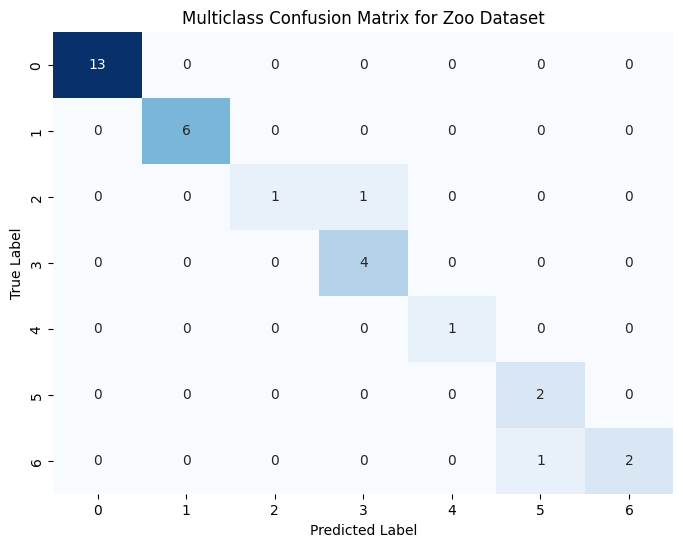

In [42]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_zoo = model_zoo.predict(X_test_zoo)

accuracy_zoo = accuracy_score(y_test_zoo, y_pred_zoo)
print(f"Multiclass Model Accuracy: {accuracy_zoo:.4f}")

print("\n--- Multiclass Classification Report ---")
print(classification_report(y_test_zoo, y_pred_zoo))

conf_matrix_zoo = confusion_matrix(y_test_zoo, y_pred_zoo)
print("\n--- Multiclass Confusion Matrix ---")
print(conf_matrix_zoo)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_zoo, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Multiclass Confusion Matrix for Zoo Dataset')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()